# Word2Vec - CBOW 模型

## 核心概念
Word2Vec 是一種將文字轉換為「向量」的技術，讓電腦能夠理解詞彙之間的語義關係。
CBOW (Continuous Bag of Words) 是 Word2Vec 的兩種實現方式之一：**用周圍的字，預測中間的字**。

## 數學原理
$$P(w_t | w_{t-k}, ..., w_{t-1}, w_{t+1}, ..., w_{t+k}) = \text{softmax}(W' \cdot \frac{1}{2k}\sum_{i} W \cdot x_i)$$

- **輸入**：目標詞周圍的上下文詞彙 (Context)
- **輸出**：預測中間的目標詞 (Target)
- **副產物**：訓練完成後，權重矩陣 $W$ 就是我們要的詞向量！

## 為什麼詞向量有用？
透過「分布假說」：**出現在相似上下文的詞，語義也相似**
- 「蘋果」和「香蕉」都出現在「吃 ___」的位置 → 向量接近
- 「狗」和「貓」都出現在「養 ___」的位置 → 向量接近

## 應用場景
- **語義相似度**：找出意思相近的詞彙
- **文本分類**：將詞向量作為特徵輸入分類器
- **命名實體識別**：利用詞向量的語義資訊
- **機器翻譯**：跨語言的詞向量對齊

In [52]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import random

# 設定隨機種子，確保每次執行結果相同
SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)

"""
第一步：準備數據與詞彙表 (Data & Vocabulary)
在餵給電腦吃之前，我們必須先把句子拆成單字，並給每個單字一個「身分證字號」（索引 Index）。
"""

# 1. 定義語料庫 (Sentences) - 極簡版本
# 設計原則：讓相同類別的詞彙出現在完全相同的上下文中
# 這樣模型會學到：出現在相同位置的詞 → 向量相似

sentences = [
    # === 水果群組：蘋果、香蕉 出現在相同的上下文 ===
    "我 喜歡 吃 蘋果",
    "我 喜歡 吃 香蕉",
    "我 喜歡 吃 水梨",
    "我 喜歡 吃 奇異果",
    
    # === 動物群組：狗、貓 出現在相同的上下文 ===
    "我 喜歡 養 狗",
    "我 喜歡 養 貓",
    "我 喜歡 養 兔子",
    "我 喜歡 養 魚",

]

# 2. 建立詞彙表 (Vocabulary)
words = ' '.join(sentences).split()
word_list = sorted(list(set(words)))

# 3. 建立映射字典
word_to_idx = {word: idx for idx, word in enumerate(word_list)}
idx_to_word = {idx: word for idx, word in enumerate(word_list)}

voc_size = len(word_list)
print("詞彙表大小：", voc_size)
print("單字對應索引：", word_to_idx)

詞彙表大小： 12
單字對應索引： {'兔子': 0, '吃': 1, '喜歡': 2, '奇異果': 3, '我': 4, '水梨': 5, '狗': 6, '蘋果': 7, '貓': 8, '養': 9, '香蕉': 10, '魚': 11}


In [54]:
"""
第二步：製作「考題」 (Dataset Generation)
CBOW 的訓練數據是透過滑動視窗 (Sliding Window) 產生的。假設句子是 "我 喜歡 吃 蘋果"，視窗大小為 2：
 - 目標 (中間字)：吃
 - 上下文 (周圍字)：我, 喜歡, 蘋果
 - 模型任務：輸入「我、喜歡、蘋果」，要預測出「吃」。
"""


def create_cbow_dataset(sentences, window_size=2):
    data = []
    for sentence in sentences:
        sentence = sentence.split()  # 切分單字
        for idx, word in enumerate(sentence):
            # 取得上下文 (Context)：當前字的前後各 window_size 個字
            # max/min 是為了防止索引超出句子範圍
            context_words = sentence[max(idx - window_size, 0):idx] \
                            + sentence[idx + 1:min(idx + window_size + 1, len(sentence))]

            # 儲存格式: (目標字, [上下文單字列表])
            data.append((word, context_words))
    return data


cbow_data = create_cbow_dataset(sentences)
print("CBOW 數據樣例 (目標, 上下文)：", cbow_data[:3])

CBOW 數據樣例 (目標, 上下文)： [('我', ['喜歡', '吃']), ('喜歡', ['我', '吃', '蘋果']), ('吃', ['我', '喜歡', '蘋果'])]


In [55]:
"""
第三步：One-Hot 編碼 (Encoding)
電腦看不懂文字，我們需要把單字變成向量。最簡單的方法是 One-Hot Encoding（獨熱編碼）。
如果詞彙表有 N 個字，每個字就是一個長度為 N 的向量，只有屬於該字的索引位置是 1，其他都是 0。
"""


def one_hot_encoding(word, word_to_idx):
    tensor = torch.zeros(len(word_to_idx))  # 建立全 0 向量
    tensor[word_to_idx[word]] = 1  # 將該單字對應的位置設為 1
    return tensor


# 測試一下
print(f"「蘋果」的 One-Hot 編碼：{one_hot_encoding('蘋果', word_to_idx)}")
print(f"「蘋果」的索引位置：{word_to_idx['蘋果']}")

「蘋果」的 One-Hot 編碼：tensor([0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.])
「蘋果」的索引位置：7


In [56]:
"""
第四步：搭建 CBOW 模型 (The Model)
這是最核心的部分。CBOW 模型的結構非常簡單，只有三層：

1. 輸入層：接收上下文單字的 One-Hot 向量。
2. 投影層 (Hidden Layer)：這是重點！我們會將上下文所有單字的向量取平均值。
3. 輸出層：預測中間那個字是誰（輸出機率）。
"""


class CBOW(nn.Module):
    def __init__(self, voc_size, embedding_size):
        super(CBOW, self).__init__()
        # 第一層權重 (輸入 -> 隱藏層)：這就是我們最後要的「詞向量 (Word Embeddings)」
        self.input_to_hidden = nn.Linear(voc_size, embedding_size, bias=False)

        # 第二層權重 (隱藏層 -> 輸出)：負責把向量轉回詞彙表的預測分數
        self.hidden_to_output = nn.Linear(embedding_size, voc_size, bias=False)

    def forward(self, X):
        # X 形狀: [上下文單字數量, 詞彙表大小]

        # 1. 轉換為嵌入向量
        embeddings = self.input_to_hidden(X)

        # 2. 這是 CBOW 的精髓：將上下文所有字的向量「取平均」
        # 這樣不管上下文有幾個字，最後都會變成一個固定大小的向量
        hidden_layer = torch.mean(embeddings, dim=0)

        # 3. 預測輸出 (增加一個維度以符合 PyTorch 格式)
        output_layer = self.hidden_to_output(hidden_layer.unsqueeze(0))
        return output_layer


# 設定嵌入層大小為 2 (為了方便最後畫在平面圖上，實際應用通常是 100~300)
embedding_size = 2
cbow_model = CBOW(voc_size, embedding_size)

In [57]:
"""
第五步：開始訓練 (Training)
我們會不斷讓模型做題目，如果做錯了（預測的字跟正確答案不一樣），就透過 Loss Function（損失函數）來懲罰它，並用 Optimizer（優化器）修正權重。
"""
learning_rate = 0.1  # 提高學習率加速收斂
epochs = 1000  # 語料庫小，不需要太多輪數
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cbow_model.parameters(), lr=learning_rate)

loss_values = []

for epoch in range(epochs):
    loss_sum = 0
    for target, context_words in cbow_data:
        if len(context_words) == 0:
            continue
            
        X = torch.stack([one_hot_encoding(word, word_to_idx) for word in context_words]).float()
        y_true = torch.tensor([word_to_idx[target]], dtype=torch.long)
        y_pred = cbow_model(X)
        
        loss = criterion(y_pred, y_true)
        loss_sum += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    avg_loss = loss_sum / len(cbow_data)
    loss_values.append(avg_loss)
    
    if (epoch + 1) % 200 == 0:
        print(f"Epoch: {epoch + 1}, Loss: {avg_loss:.4f}")

Epoch: 200, Loss: 0.7548
Epoch: 400, Loss: 0.7556
Epoch: 600, Loss: 0.7557
Epoch: 800, Loss: 0.7515
Epoch: 1000, Loss: 0.7539


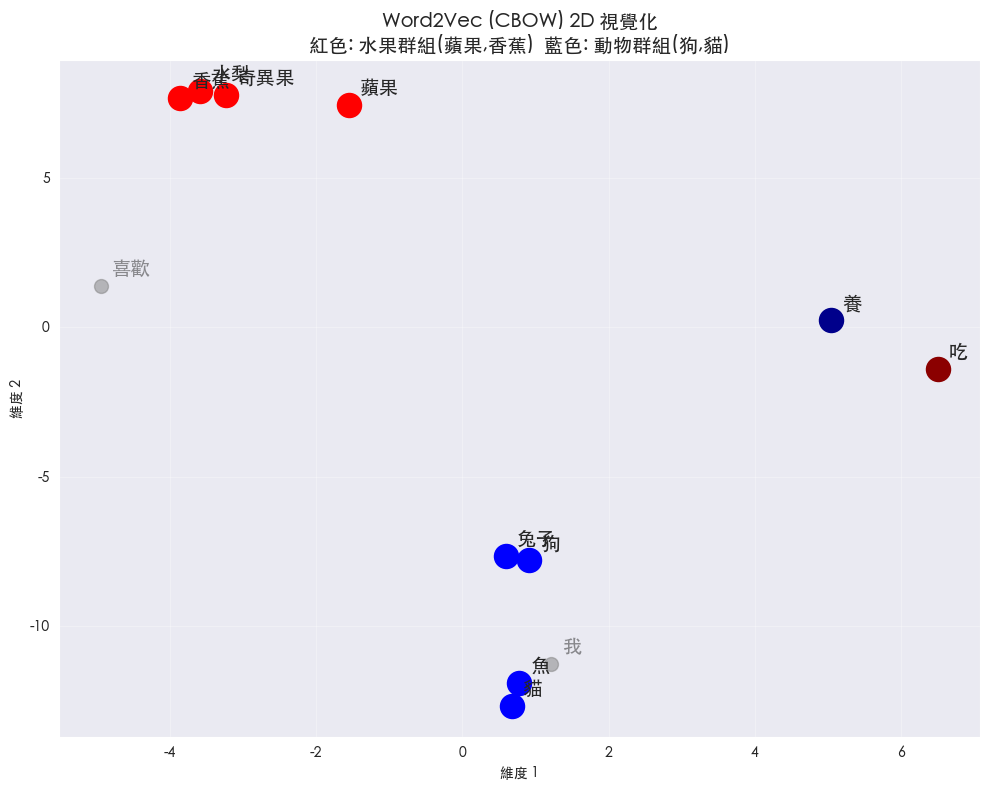

In [59]:
"""
第六步：結果可視化 (Visualization)
訓練完成後，模型第一層的權重 (input_to_hidden) 就是我們夢寐以求的 Word Vectors。因為我們設定維度是 2，所以可以直接畫在圖表上。

預期結果：
- 蘋果、香蕉 應該距離很近（都是水果，出現在「吃」之後）
- 狗、貓 應該距離很近（都是動物，出現在「養」之後）
"""
# 設定中文字體
import platform
if platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.sans-serif'] = ['PingFang TC', 'Heiti TC', 'Arial Unicode MS']
elif platform.system() == 'Windows':
    plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'SimHei']
else:  # Linux
    plt.rcParams['font.sans-serif'] = ['Noto Sans CJK TC', 'WenQuanYi Micro Hei']
plt.rcParams['axes.unicode_minus'] = False

# 定義不同類別的顏色
color_map = {
    # 水果群組 - 紅色
    '蘋果': 'red', '香蕉': 'red', '水梨': 'red', '奇異果': 'red', '吃': 'darkred',
    # 動物群組 - 藍色
    '狗': 'blue', '貓': 'blue', '兔子': 'blue', '魚': 'blue', '養': 'darkblue',
}

fig, ax = plt.subplots(figsize=(10, 8))
for word, idx in word_to_idx.items():
    vec = cbow_model.input_to_hidden.weight[:, idx].detach().numpy()
    color = color_map.get(word, 'gray')
    
    # 重點詞彙用大點，其他用小點
    size = 300 if word in color_map else 100
    alpha = 1.0 if word in color_map else 0.5
    
    ax.scatter(vec[0], vec[1], c=color, s=size, alpha=alpha)
    ax.annotate(word, (vec[0], vec[1]), fontsize=14, fontweight='bold' if word in color_map else 'normal',
                xytext=(8, 8), textcoords='offset points',
                alpha=alpha)

plt.title('Word2Vec (CBOW) 2D 視覺化\n紅色: 水果群組(蘋果,香蕉)  藍色: 動物群組(狗,貓)', fontsize=14)
plt.xlabel('維度 1')
plt.ylabel('維度 2')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 為什麼會出現向量聚集現象？

從上圖可以觀察到：**「蘋果」和「香蕉」的向量很接近，「狗」和「貓」的向量也很接近**。這個現象的核心原因是：

### 分布假說 (Distributional Hypothesis)

> **「出現在相似上下文中的詞，具有相似的語義」**
> — J.R. Firth (1957): "You shall know a word by the company it keeps."

### 具體解釋

在我們的語料庫中：
- `"我 喜歡 吃 蘋果"` 和 `"我 喜歡 吃 香蕉"`
- `"我 喜歡 養 狗"` 和 `"我 喜歡 養 貓"`

**「蘋果」和「香蕉」共享完全相同的上下文**（都在「吃」之後），所以：
1. CBOW 模型在訓練時，需要用「我、喜歡、吃」來預測「蘋果」
2. 同樣地，也需要用「我、喜歡、吃」來預測「香蕉」
3. 為了讓這兩個預測都正確，模型會**調整「蘋果」和「香蕉」的向量，使它們在向量空間中靠近**

### 數學直覺

CBOW 的目標是：給定上下文，最大化預測目標詞的機率。

當兩個詞 A 和 B 出現在相同的上下文時：
- 模型必須讓 `P(A|context)` 和 `P(B|context)` 都變大
- 這導致 A 和 B 的向量被「推」向相似的位置

### Word2Vec 的威力

透過這種方式，Word2Vec 能夠自動從文本中學習到：
- **語義相似性**：蘋果 ≈ 香蕉（都是水果）
- **語法相似性**：動詞和動詞會聚在一起